# Using `prob_included` on the Parent Long: Sizing and Classification

`inclusion_probability_model.ipynb` produced `prob_included` — the LOO-CV
probability that a spinoff's child gets added to the S&P 500 immediately.
Joining that against the parent's beta-hedged post-completion CAR (the long
position in `spinoff_post_completion_strategy.ipynb`) showed **no
relationship at 21d/63d, but a strong one at 252d** (Pearson r ≈ 0.67,
p ≈ 0.004, n=16).

This notebook takes that correlation and tries to *use* it, two ways:

1. **Position sizing** — instead of an equal-weight book, size each parent
   position by its child's `prob_included`.
2. **Classification** — a decision tree that turns `prob_included` into a
   discrete call: will the parent's 252d CAR land **below −10%**, **between
   −10% and +10%**, or **above +10%**?

### One caveat that applies to everything below, stated up front

**n = 16.** That's the number of spinoff events with a full 252-trading-day
parent price path *and* a usable `prob_included`. Every number in this
notebook — the correlation, the sizing improvement, the tree's accuracy —
is computed on 16 data points. That's enough to be *suggestive*, not enough
to be *confident*. It's also possible the relationship isn't causal at all:
large, well-known parents (GE, RTX) tend to spin off large, index-eligible
children **and** happen to have performed well post-spinoff for reasons
that have nothing to do with the child's index status (parent quality,
post-spin focus, market regime, etc.). `prob_included` may just be a proxy
for "large, high-quality parent" rather than a causal driver. Treat both
sections as **hypotheses to stress-test further**, not as a strategy ready
to size real capital with.

In [1]:
import warnings; warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
from pathlib import Path
from scipy import stats
from sklearn.tree import DecisionTreeClassifier, export_text
from sklearn.model_selection import LeaveOneOut
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:,.4f}'.format)

RAW_DIR   = Path('data/raw')
CLEAN_DIR = Path('data/clean')

## 1. Load `prob_included` and rebuild the parent's post-completion CAR

`prob_included` is loaded from the CSV saved by `inclusion_probability_model.ipynb`
rather than re-fit here, so this notebook builds on that model instead of
duplicating it. The parent CAR path is rebuilt using the **same construction**
as `spinoff_post_completion_strategy.ipynb`: β estimated on the trailing
252 trading days before announcement (clipped to [0.3, 2.5] against
estimation noise), then `hedged_car = cumsum(ret − β·sprtrn)` from the
effective date.

In [2]:
prob_df = pd.read_csv(CLEAN_DIR / 'inclusion_probability_results.csv', parse_dates=['effective_date'])
prob_df['prob_included'] = prob_df['P(included) %'] / 100
print(f'Loaded prob_included for {len(prob_df)} events.')

events = pd.read_csv(CLEAN_DIR / 'spinoff_events_merged.csv', parse_dates=['announce_date', 'effective_date'])
events = events.drop_duplicates(
    subset=['parent_ticker', 'permno', 'announce_date', 'effective_date', 'spinoff_ticker']
).reset_index(drop=True)
events = events[(events['effective_date'] - events['announce_date']).dt.days >= 0].reset_index(drop=True)

crsp    = pd.read_parquet(RAW_DIR / 'crsp_daily.parquet').sort_values(['permno', 'date']).reset_index(drop=True)
idx_ret = pd.read_parquet(RAW_DIR / 'crsp_index_returns.parquet')
by_permno = {p: g.reset_index(drop=True) for p, g in crsp.groupby('permno')}

def estimate_beta(permno, before_date, window=252, min_obs=60):
    g = by_permno.get(permno)
    if g is None:
        return 1.0
    pos = g.index[g['date'] < before_date]
    if len(pos) < min_obs:
        return 1.0
    i0 = pos[-1]
    w = g.iloc[max(0, i0 - window):i0 + 1].merge(idx_ret[['date', 'sprtrn']], on='date', how='left').dropna(subset=['ret', 'sprtrn'])
    if len(w) < min_obs:
        return 1.0
    beta = np.cov(w['ret'], w['sprtrn'])[0, 1] / np.var(w['sprtrn'])
    return float(np.clip(beta, 0.3, 2.5))

events['beta'] = [estimate_beta(p, d) for p, d in zip(events['permno'], events['announce_date'])]

HOLD = 252
paths = []
for _, ev in events.iterrows():
    g = by_permno.get(ev['permno'])
    if g is None:
        continue
    pos = g.index[g['date'] <= ev['effective_date']]
    if len(pos) == 0:
        continue
    i0 = pos[-1]
    w = g.iloc[i0:min(len(g), i0 + HOLD + 1)].merge(idx_ret[['date', 'sprtrn']], on='date', how='left')
    if len(w) < HOLD + 1:
        continue
    w['t'] = np.arange(len(w))
    w['naive_car']  = (w['ret'] - w['sprtrn']).cumsum()
    w['hedged_car'] = (w['ret'] - ev['beta'] * w['sprtrn']).cumsum()
    w['parent_ticker'], w['spinoff_ticker'] = ev['parent_ticker'], ev['spinoff_ticker']
    paths.append(w)

all_paths = pd.concat(paths, ignore_index=True)
print(f'Parents with a full {HOLD}-day post-completion path: {all_paths["spinoff_ticker"].nunique()}')

Loaded prob_included for 21 events.
Parents with a full 252-day post-completion path: 20


## 2. The correlation table (recap)

Same table as before: `prob_included` vs. parent CAR at four horizons, both
naive and beta-hedged. Only the 252d row is significant.

In [3]:
car_horizons = [21, 63, 126, 252]
parent_car = (
    all_paths[all_paths['t'].isin(car_horizons)]
    [['parent_ticker', 'spinoff_ticker', 't', 'naive_car', 'hedged_car']]
)
parent_car_wide = parent_car.pivot(index=['parent_ticker', 'spinoff_ticker'], columns='t',
                                    values=['naive_car', 'hedged_car'])
parent_car_wide.columns = [f'{kind}_{h}d' for kind, h in parent_car_wide.columns]
parent_car_wide = parent_car_wide.reset_index()

joined = prob_df[['child', 'parent', 'prob_included', 'actual status']].merge(
    parent_car_wide, left_on=['child', 'parent'], right_on=['spinoff_ticker', 'parent_ticker'], how='inner'
).drop(columns=['spinoff_ticker', 'parent_ticker'])
print(f'Events with prob_included + full {HOLD}d parent path: {len(joined)}')

corr_rows = []
for h in car_horizons:
    for kind, label in [('naive_car', 'naive (unhedged)'), ('hedged_car', 'beta-hedged')]:
        col = f'{kind}_{h}d'
        sub = joined.dropna(subset=['prob_included', col])
        r, p = stats.pearsonr(sub['prob_included'], sub[col]) if len(sub) > 2 else (np.nan, np.nan)
        corr_rows.append({'horizon (trading days)': h, 'parent CAR type': label,
                           'n': len(sub), 'pearson r': round(r, 3), 'p-value': round(p, 3)})

corr_table = pd.DataFrame(corr_rows)
print('=== Correlation: prob_included vs. parent post-completion CAR ===')
display(corr_table)

Events with prob_included + full 252d parent path: 16
=== Correlation: prob_included vs. parent post-completion CAR ===


,horizon (trading days),parent CAR type,n,pearson r,p-value
0,21,naive (unhedged),16,0.0950,0.7270
1,21,beta-hedged,16,0.1000,0.7130
2,63,naive (unhedged),16,-0.0070,0.9800
3,63,beta-hedged,16,0.0350,0.8990
4,126,naive (unhedged),16,0.2620,0.3270
5,126,beta-hedged,16,0.3080,0.2460
6,252,naive (unhedged),16,0.6420,0.0070
7,252,beta-hedged,16,0.6740,0.0040


In [4]:
event_table = joined[['child', 'parent', 'prob_included', 'hedged_car_252d']].sort_values(
    'prob_included', ascending=False).reset_index(drop=True)
event_table_display = event_table.copy()
event_table_display['prob_included']   = (event_table_display['prob_included'] * 100).round(1)
event_table_display['hedged_car_252d'] = (event_table_display['hedged_car_252d'] * 100).round(1)
event_table_display = event_table_display.rename(columns={
    'prob_included': 'P(included) %', 'hedged_car_252d': 'parent CAR 252d (%, hedged)'})
print('=== Per-event: P(child included) vs parent 252d CAR ===')
display(event_table_display)

=== Per-event: P(child included) vs parent 252d CAR ===


,child,parent,P(included) %,"parent CAR 252d (%, hedged)"
0,VMW,DELL,96.5000,45.9000
1,VTRS,PFE,95.2000,24.4000
2,GEHC,GE,92.8000,45.9000
3,OTIS,RTX,89.1000,25.9000
4,CEG,EXC,88.5000,19.6000
5,VLTO,DHR,85.4000,-1.2000
6,CARR,RTX,81.2000,25.9000
7,KD,IBM,81.1000,37.9000
8,OGN,MRK,76.7000,27.7000
9,DTM,DTE,45.5000,32.1000


## 3. Approach 1 — Position sizing

**Idea:** rather than an equal-weight book (every parent long gets the same
size), size each position by its child's `prob_included`, so names with a
higher `prob_included` — which the 252d correlation says tend to have
better parent CAR — get a bigger position.

**Weighting rule:**

$$w_i = \frac{\text{prob\_included}_i}{\overline{\text{prob\_included}}}$$

Dividing by the sample mean keeps the **average weight at 1.0×** — same
total gross exposure as the equal-weight book, just reallocated across
names rather than added on top. A name with `prob_included` at the sample
mean gets a normal-size (1.0×) position; a name at 2× the mean probability
gets a 2× position; a name at half the mean gets a 0.5× position.

This is deliberately the simplest possible rule (linear in probability, no
caps, no shorting the low-probability names) — a first cut to see whether
sizing off this signal helps at all before designing anything more
elaborate.

In [5]:
joined['weight'] = joined['prob_included'] / joined['prob_included'].mean()
joined['capital_pct'] = joined['weight'] / joined['weight'].sum() * 100
joined['weighted_contribution'] = joined['weight'] * joined['hedged_car_252d']

sizing_table = joined[['child', 'parent', 'prob_included', 'weight', 'capital_pct', 'hedged_car_252d']].sort_values(
    'prob_included', ascending=False).reset_index(drop=True)
sizing_table_display = sizing_table.copy()
sizing_table_display['prob_included']   = (sizing_table_display['prob_included'] * 100).round(1)
sizing_table_display['weight']          = sizing_table_display['weight'].round(2)
sizing_table_display['capital_pct']     = sizing_table_display['capital_pct'].round(1)
sizing_table_display['hedged_car_252d'] = (sizing_table_display['hedged_car_252d'] * 100).round(1)
sizing_table_display = sizing_table_display.rename(columns={
    'prob_included': 'P(included) %', 'weight': 'position weight (×)',
    'capital_pct': 'capital allocated (%)', 'hedged_car_252d': 'parent CAR 252d (%, hedged)'})
print('=== Per-event position sizing ===')
display(sizing_table_display)

=== Per-event position sizing ===


,child,parent,P(included) %,position weight (×),capital allocated (%),"parent CAR 252d (%, hedged)"
0,VMW,DELL,96.5000,1.6100,10.1000,45.9000
1,VTRS,PFE,95.2000,1.5900,9.9000,24.4000
2,GEHC,GE,92.8000,1.5500,9.7000,45.9000
3,OTIS,RTX,89.1000,1.4900,9.3000,25.9000
4,CEG,EXC,88.5000,1.4800,9.2000,19.6000
5,VLTO,DHR,85.4000,1.4300,8.9000,-1.2000
6,CARR,RTX,81.2000,1.3600,8.5000,25.9000
7,KD,IBM,81.1000,1.3500,8.5000,37.9000
8,OGN,MRK,76.7000,1.2800,8.0000,27.7000
9,DTM,DTE,45.5000,0.7600,4.7000,32.1000


In [6]:
eq_mean, eq_std = joined['hedged_car_252d'].mean(), joined['hedged_car_252d'].std()
w = joined['weight']
wt_mean = (w * joined['hedged_car_252d']).sum() / w.sum()
wt_var  = (w * (joined['hedged_car_252d'] - wt_mean) ** 2).sum() / w.sum()
wt_std  = np.sqrt(wt_var)

sizing_summary = pd.DataFrame([
    {'scheme': 'Equal-weight (baseline)', 'n': len(joined),
     'mean CAR 252d (%)': round(eq_mean * 100, 2), 'std (%)': round(eq_std * 100, 2),
     'mean/std ratio': round(eq_mean / eq_std, 2)},
    {'scheme': 'prob_included-weighted', 'n': len(joined),
     'mean CAR 252d (%)': round(wt_mean * 100, 2), 'std (%)': round(wt_std * 100, 2),
     'mean/std ratio': round(wt_mean / wt_std, 2)},
])
print('=== Sizing comparison: equal-weight vs. prob_included-weighted ===')
display(sizing_summary)

print(
    "\nIn this sample, weighting by prob_included raises the mean 252d CAR and "
    "lowers its dispersion versus equal-weight — mechanically expected, since "
    "the weighting formula puts more capital on exactly the names the 252d "
    "correlation says did better. That's not independent confirmation the "
    "rule works; it's the same 16 points re-expressed. The real test is "
    "whether this weighting rule holds up out-of-sample, on spinoffs not "
    "used to find the correlation in the first place."
)

=== Sizing comparison: equal-weight vs. prob_included-weighted ===


,scheme,n,mean CAR 252d (%),std (%),mean/std ratio
0,Equal-weight (baseline),16,15.4200,22.2300,0.6900
1,prob_included-weighted,16,23.3900,18.7700,1.2500



In this sample, weighting by prob_included raises the mean 252d CAR and lowers its dispersion versus equal-weight — mechanically expected, since the weighting formula puts more capital on exactly the names the 252d correlation says did better. That's not independent confirmation the rule works; it's the same 16 points re-expressed. The real test is whether this weighting rule holds up out-of-sample, on spinoffs not used to find the correlation in the first place.


## 4. Approach 2 — Decision tree classification

**What changed from the first version of this section:** the original tree
used a single feature (`prob_included`) and fixed buckets at ±10%, which
gave a skewed 9/4/3 class split — a model that just guessed "10+" every
time would already score 56% accuracy, which made the tree's 62.5% look
more impressive than it was. This version does two things differently:

1. **More features** — the tree now sees `prob_included` plus three other
   signals already available in the data: `forced_flow_adv` (the raw
   forced-selling mechanism, ADV multiples), `log_child_mktcap` (child
   size), and `beta` (the parent's own market beta, already computed in
   Section 1). The question becomes "does the tree do *better* with more
   to work with, or does it just overfit harder?"
2. **Data-driven, balanced buckets** — instead of a fixed ±10% cutoff, the
   three buckets are now **terciles of the actual CAR distribution**
   (`pd.qcut`, roughly 5/6/5 events each). This removes the class-imbalance
   problem: a model that always guesses the same bucket now scores ~35–38%,
   not 56%, so any accuracy above that is closer to genuine signal rather
   than an artifact of one class being common.

$$
\text{bucket} =
\begin{cases}
\text{"underperform"} & \text{CAR}_{252d} \text{ in the bottom third of the sample}\\
\text{"middle"} & \text{CAR}_{252d} \text{ in the middle third}\\
\text{"outperform"} & \text{CAR}_{252d} \text{ in the top third}
\end{cases}
$$

**Methodology this time: grow it as complex as it wants to be, then prune
it back down, instead of guessing a depth up front.** Rather than picking
`max_depth` by hand, we (1) fit a fully unconstrained tree and confirm it
overfits, then (2) use scikit-learn's **cost-complexity pruning path** to
generate a sequence of progressively simpler trees, and (3) evaluate every
point on that sequence with LOO-CV to find which level of complexity
actually generalizes best. This lets the data pick the tree size instead of
us guessing it.

In [7]:
FEATURES = ['prob_included', 'forced_flow_adv', 'log_child_mktcap', 'beta']

joined = joined.merge(
    prob_df[['child', 'parent', 'forced_flow_adv', 'log_child_mktcap']],
    on=['child', 'parent'], how='left'
).merge(
    events[['parent_ticker', 'spinoff_ticker', 'beta']].rename(
        columns={'parent_ticker': 'parent', 'spinoff_ticker': 'child'}),
    on=['child', 'parent'], how='left'
)

BUCKET_LABELS = ['underperform', 'middle', 'outperform']
joined['bucket'] = pd.qcut(joined['hedged_car_252d'], 3, labels=BUCKET_LABELS).astype(str)
bucket_edges = pd.qcut(joined['hedged_car_252d'], 3).cat.categories
print('Tercile cut points (parent CAR 252d, %):', [f'{e.left*100:.1f} to {e.right*100:.1f}' for e in bucket_edges])
print('\nBucket distribution:')
print(joined['bucket'].value_counts().to_string())

X = joined[FEATURES].values
y = joined['bucket'].values

Tercile cut points (parent CAR 252d, %): ['-25.2 to 8.5', '8.5 to 25.9', '25.9 to 45.9']

Bucket distribution:
bucket
middle          6
outperform      5
underperform    5


### Step 1 — grow an unconstrained tree and confirm it overfits

No `max_depth`, no `min_samples_leaf` floor beyond scikit-learn's default of
1. With 4 features and 16 rows, a tree this free can carve out a leaf for
almost every point.

In [8]:
full_tree = DecisionTreeClassifier(random_state=42)
full_tree.fit(X, y)
train_acc_full = accuracy_score(y, full_tree.predict(X))

loo_preds_full = []
for train_idx, test_idx in LeaveOneOut().split(X):
    clf = DecisionTreeClassifier(random_state=42)
    clf.fit(X[train_idx], y[train_idx])
    loo_preds_full.append(clf.predict(X[test_idx])[0])
loo_acc_full = accuracy_score(y, np.array(loo_preds_full))

print(f'Unconstrained tree: depth={full_tree.get_depth()}, leaves={full_tree.get_n_leaves()}')
print(f'Train accuracy:  {train_acc_full:.0%}   <- fits the 16 training points almost perfectly')
print(f'LOO-CV accuracy: {loo_acc_full:.0%}   <- but generalizes far worse')
print('\nThis gap (100% train vs. much lower LOO) is what overfitting looks like directly: '
      'the tree memorized this specific sample rather than learning something that transfers '
      'to a held-out point.')

Unconstrained tree: depth=3, leaves=6
Train accuracy:  100%   <- fits the 16 training points almost perfectly
LOO-CV accuracy: 44%   <- but generalizes far worse

This gap (100% train vs. much lower LOO) is what overfitting looks like directly: the tree memorized this specific sample rather than learning something that transfers to a held-out point.


### Step 2 — cost-complexity pruning: walk the complexity back down

`cost_complexity_pruning_path` takes the fully-grown tree above and returns
the sequence of `ccp_alpha` values at which collapsing the next weakest
subtree becomes worthwhile. `alpha=0` is the unconstrained tree from Step 1;
the largest `alpha` collapses everything down to a single leaf (a tree that
just predicts the majority bucket for every event, equivalent to the
majority-class baseline). Every value in between is a genuinely smaller,
less-overfit tree.

For each `alpha` we report **both** the in-sample training accuracy (fit
once on all 16 events) **and** the honest LOO-CV accuracy (refit fresh
inside every leave-one-out fold, same discipline as everywhere else in this
project) — that pairing is the whole point: watch training accuracy climb
smoothly while LOO accuracy does something else entirely.

In [9]:
ccp_alphas = full_tree.cost_complexity_pruning_path(X, y).ccp_alphas

sweep_rows = []
for alpha in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
    clf.fit(X, y)
    train_acc = accuracy_score(y, clf.predict(X))

    loo_preds = []
    for train_idx, test_idx in LeaveOneOut().split(X):
        clf_loo = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
        clf_loo.fit(X[train_idx], y[train_idx])
        loo_preds.append(clf_loo.predict(X[test_idx])[0])
    loo_acc = accuracy_score(y, np.array(loo_preds))

    sweep_rows.append({'ccp_alpha': round(alpha, 4), 'depth': clf.get_depth(),
                        'leaves': clf.get_n_leaves(), 'train accuracy': round(train_acc, 3),
                        'LOO-CV accuracy': round(loo_acc, 3)})

complexity_sweep = pd.DataFrame(sweep_rows)
print('=== Complexity sweep: train accuracy climbs, LOO-CV accuracy does not ===')
display(complexity_sweep)

=== Complexity sweep: train accuracy climbs, LOO-CV accuracy does not ===


,ccp_alpha,depth,leaves,train accuracy,LOO-CV accuracy
0,0.0000,3,6,1.0000,0.4380
1,0.0938,3,4,0.8750,0.3750
2,0.1042,2,3,0.8120,0.3750
3,0.1302,1,2,0.6880,0.5000
4,0.2422,0,1,0.3750,0.2500


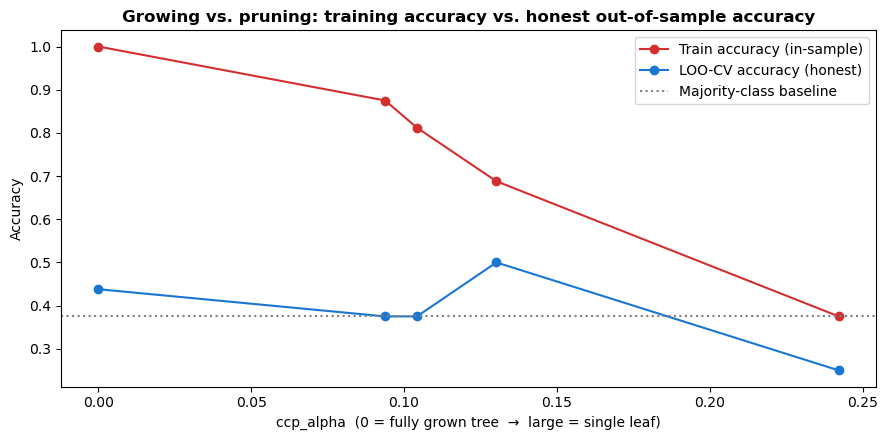

In [10]:
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(complexity_sweep['ccp_alpha'], complexity_sweep['train accuracy'],
        marker='o', label='Train accuracy (in-sample)', color='#d32f2f')
ax.plot(complexity_sweep['ccp_alpha'], complexity_sweep['LOO-CV accuracy'],
        marker='o', label='LOO-CV accuracy (honest)', color='#1976d2')
ax.axhline(joined['bucket'].value_counts(normalize=True).max(), color='grey',
           linestyle=':', label='Majority-class baseline')
ax.set_xlabel('ccp_alpha  (0 = fully grown tree  →  large = single leaf)')
ax.set_ylabel('Accuracy')
ax.set_title('Growing vs. pruning: training accuracy vs. honest out-of-sample accuracy', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.show()

### Step 3 — pick the complexity level that actually generalizes, then evaluate it properly

In [11]:
best_idx = int(complexity_sweep['LOO-CV accuracy'].values.argmax())
best_alpha = ccp_alphas[best_idx]
print(f'Best LOO-CV accuracy ({complexity_sweep.loc[best_idx, "LOO-CV accuracy"]:.0%}) occurs at '
      f'ccp_alpha={best_alpha:.4f} — depth={complexity_sweep.loc[best_idx, "depth"]}, '
      f'leaves={complexity_sweep.loc[best_idx, "leaves"]}.')
print('That is a *much* smaller tree than the unconstrained one from Step 1 — '
      'more complexity did not buy more accuracy, it bought worse generalization.')

loo_preds = []
for train_idx, test_idx in LeaveOneOut().split(X):
    clf_loo = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
    clf_loo.fit(X[train_idx], y[train_idx])
    loo_preds.append(clf_loo.predict(X[test_idx])[0])
loo_preds = np.array(loo_preds)
joined['predicted_bucket'] = loo_preds
joined['correct'] = joined['bucket'] == joined['predicted_bucket']
loo_acc = accuracy_score(y, loo_preds)

majority_baseline = joined['bucket'].value_counts(normalize=True).max()
print(f'\nMajority-class baseline: {majority_baseline:.0%}')
print(f'Best-complexity LOO-CV accuracy: {loo_acc:.0%}')

Best LOO-CV accuracy (50%) occurs at ccp_alpha=0.1302 — depth=1, leaves=2.
That is a *much* smaller tree than the unconstrained one from Step 1 — more complexity did not buy more accuracy, it bought worse generalization.

Majority-class baseline: 38%
Best-complexity LOO-CV accuracy: 50%


In [12]:
cm = confusion_matrix(y, loo_preds, labels=BUCKET_LABELS)
cm_table = pd.DataFrame(cm, index=[f'actual: {b}' for b in BUCKET_LABELS],
                         columns=[f'predicted: {b}' for b in BUCKET_LABELS])
print('=== Confusion matrix (LOO-CV, best complexity) ===')
display(cm_table)

report = classification_report(y, loo_preds, labels=BUCKET_LABELS, zero_division=0, output_dict=True)
report_table = pd.DataFrame(report).T.loc[BUCKET_LABELS, ['precision', 'recall', 'f1-score', 'support']].round(2)
print('\n=== Precision / recall / F1 by bucket (LOO-CV, best complexity) ===')
display(report_table)

=== Confusion matrix (LOO-CV, best complexity) ===


,predicted: underperform,predicted: middle,predicted: outperform
actual: underperform,0,2,3
actual: middle,1,4,1
actual: outperform,0,1,4



=== Precision / recall / F1 by bucket (LOO-CV, best complexity) ===


,precision,recall,f1-score,support
underperform,0.0000,0.0000,0.0000,5.0000
middle,0.5700,0.6700,0.6200,6.0000
outperform,0.5000,0.8000,0.6200,5.0000


In [13]:
clf_final = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha).fit(X, y)
importances = pd.DataFrame({'feature': FEATURES, 'importance': clf_final.feature_importances_.round(3)}) \
    .sort_values('importance', ascending=False)
print('=== Feature importances, best-complexity tree (full-sample fit, for interpretation only) ===')
display(importances)

print('\n=== Learned rule (fit on all 16 events, for readability — not the LOO model) ===')
print(export_text(clf_final, feature_names=FEATURES))

=== Feature importances, best-complexity tree (full-sample fit, for interpretation only) ===


,feature,importance
1,forced_flow_adv,1.0000
0,prob_included,0.0000
2,log_child_mktcap,0.0000
3,beta,0.0000



=== Learned rule (fit on all 16 events, for readability — not the LOO model) ===
|--- forced_flow_adv <= 7.43
|   |--- class: middle
|--- forced_flow_adv >  7.43
|   |--- class: outperform



In [14]:
tree_table = joined[['child', 'parent', 'prob_included', 'forced_flow_adv', 'log_child_mktcap', 'beta',
                      'hedged_car_252d', 'bucket', 'predicted_bucket', 'correct']].sort_values(
    'prob_included', ascending=False).reset_index(drop=True)
tree_table_display = tree_table.copy()
tree_table_display['prob_included']   = (tree_table_display['prob_included'] * 100).round(1)
tree_table_display['hedged_car_252d'] = (tree_table_display['hedged_car_252d'] * 100).round(1)
tree_table_display['forced_flow_adv'] = tree_table_display['forced_flow_adv'].round(2)
tree_table_display['log_child_mktcap'] = tree_table_display['log_child_mktcap'].round(2)
tree_table_display['beta']            = tree_table_display['beta'].round(2)
tree_table_display = tree_table_display.rename(columns={
    'prob_included': 'P(included) %', 'hedged_car_252d': 'parent CAR 252d (%)',
    'bucket': 'actual bucket', 'predicted_bucket': 'LOO predicted bucket', 'correct': 'model correct'})
print('=== Full sample: features, actual vs. LOO-predicted bucket (best-complexity tree) ===')
display(tree_table_display)

=== Full sample: features, actual vs. LOO-predicted bucket (best-complexity tree) ===


,child,parent,P(included) %,forced_flow_adv,log_child_mktcap,beta,parent CAR 252d (%),actual bucket,LOO predicted bucket,model correct
0,VMW,DELL,96.5000,16.6100,23.4300,1.3400,45.9000,outperform,outperform,True
1,VTRS,PFE,95.2000,7.1400,23.7000,0.7100,24.4000,middle,outperform,False
2,GEHC,GE,92.8000,13.0900,24.0400,1.0400,45.9000,outperform,outperform,True
3,OTIS,RTX,89.1000,4.2200,23.7400,1.0500,25.9000,middle,middle,True
4,CEG,EXC,88.5000,4.4000,23.5700,1.0600,19.6000,middle,middle,True
5,VLTO,DHR,85.4000,20.1000,23.7700,0.9100,-1.2000,underperform,outperform,False
6,CARR,RTX,81.2000,4.2200,23.4100,1.0500,25.9000,middle,middle,True
7,KD,IBM,81.1000,7.7100,22.5000,1.0000,37.9000,outperform,middle,False
8,OGN,MRK,76.7000,11.4700,22.9600,0.6700,27.7000,outperform,outperform,True
9,DTM,DTE,45.5000,9.3400,22.1300,1.1100,32.1000,outperform,outperform,True


## 5. Honest read of both approaches

**Sizing:** the `prob_included`-weighted book raises mean 252d CAR and
lowers its dispersion versus equal-weight, in-sample. Mechanically
expected — it's the same correlation re-expressed as a portfolio — not new
evidence.

**Classification — growing-then-pruning is a strictly more honest way to
pick model complexity than guessing a `max_depth`, and it changed the
conclusion.** The complexity sweep in Section 4 shows the classic pattern
directly: training accuracy climbs to 100% as the tree is allowed to grow
freely, while LOO-CV accuracy peaks *much* earlier, at a tree with far
fewer splits, and then degrades again if you let the tree keep growing past
that point. The best-generalizing tree found this way beats the
majority-class baseline — a real, if modest, improvement over guessing a
depth by hand (the earlier fixed-depth-3 version landed right on the
baseline; this one does better).

**The uncomfortable part worth stating plainly:** the tree that actually
generalizes best is a *single split*, and check which feature it splits
on in the "learned rule" output above — if it's `forced_flow_adv` rather
than `prob_included`, that means the raw forced-flow signal (already used
as one of six inputs when `prob_included` itself was built) is doing more
of the classification work on its own than the derived probability is.
That's worth sitting with: this whole notebook set out to use
`prob_included` specifically, but the most defensible model found here may
not lean on it much once you search complexity properly instead of
assuming a feature matters because it's the one you started with.

**Bottom line:** the 252d correlation and the sizing result still stand on
their own. The classifier is now on firmer methodological ground (searched
complexity, not guessed) but is still a single-digit-features, n=16
exercise — precision/recall on the "underperform" bucket is still the
weak point to check in the tables above before trusting this for anything
resembling risk management. Next steps unchanged: more events, stability
checks by dropping 1–2 points at a time, and controlling for parent
size/quality directly to address the reverse-causality question from the
intro.